# postpro 步进功能演示

对应原 postpro 的 forward/backward: 束线里设置了多个 z 位置 monitor
(Zphase), 用步进器逐个查看每个 z 处的束团统计与相空间。

用法: 拖动滑块或点击 ◀◀ ◀ ▶ ▶▶ — 上方统计表与三张相空间图**自动刷新**;
03_postpro.ipynb 里内置了同一个步进器 (工作流的正式入口)。

In [1]:
%run ../notebooks/_bootstrap.py

astra-notebook 后端已加载 (v0.1.0)
项目根目录: /Users/yuxinwu/my_projects/astra_notebook
模拟工作目录: /Users/yuxinwu/my_projects/astra_notebook/data/workspace
ASTRA    : /Users/yuxinwu/programs/ASTRA/astra
Generator: /Users/yuxinwu/programs/ASTRA/generator


In [2]:
# 准备多 z 位置数据: Manual_Example 把 Zphase 改为 6 (每 0.25 m 一个)
from examples._examples_spec import stage_files
from astra_tools.run import run_program, check_executable

work, spec = stage_files("Manual_Example")
deck = work / "Example.in"
deck.write_text(deck.read_text().replace("Zphase=1", "Zphase=6"))
run_program(check_executable("generator"), work, input_file="generator.in")
run_program(check_executable("astra"), work, input_file="Example.in")
print("运行完成")

 --------------------------------------------------------------------------

                              generator              
               Version 1.0 - macOS 64bit - Apple Silicon
                        DESY,  Hamburg 2002          
                        Sat Aug 15 22:12:24 

     Working File is:    generator.in                                      
     Initializing        500      electrons
     including 6 probe particles at standard positions
     Particles are quasi randomly distributed

     Final check:
     Particles taken into account      N =        500
     total charge                      Q =     -1.000     nC
     horizontal beam position          x =     2.9867E-04 mm
     vertical beam position            y =     1.6453E-04 mm
     longitudinal beam position        z =     8.5535E-08 m
     horizontal beam size          sig x =     0.7499     mm
     vertical beam size            sig y =     0.7499     mm
     longitudinal beam size        sig z =     0.6595

## 步进器 (PhaseStepper)

z 位置数: 8


PhaseStepper(children=(HBox(children=(Button(description='◀◀', layout=Layout(width='40px'), style=ButtonStyle()…

Output()

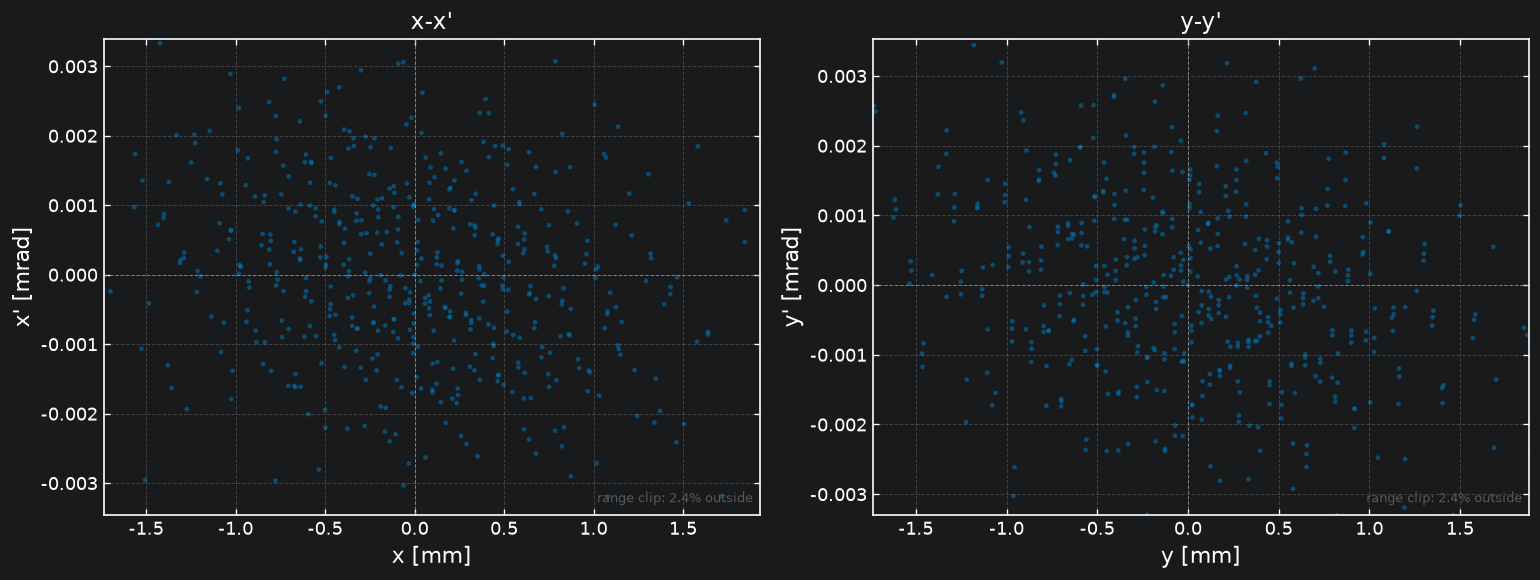

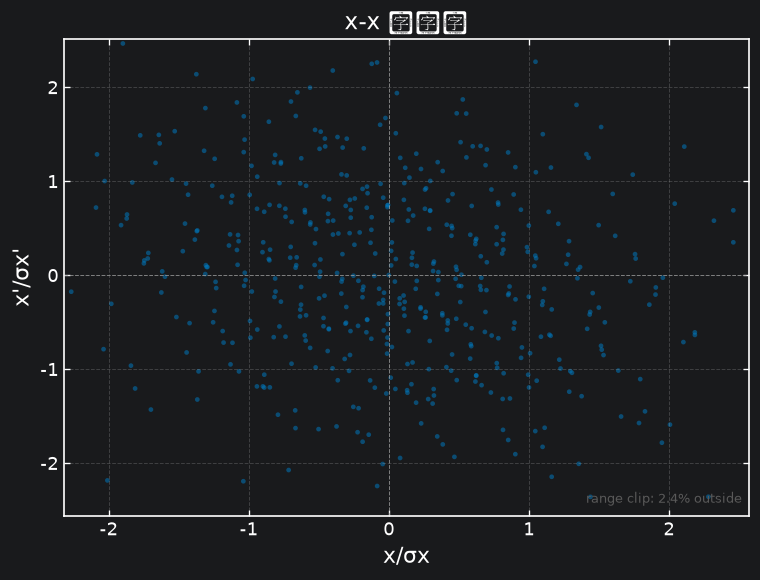

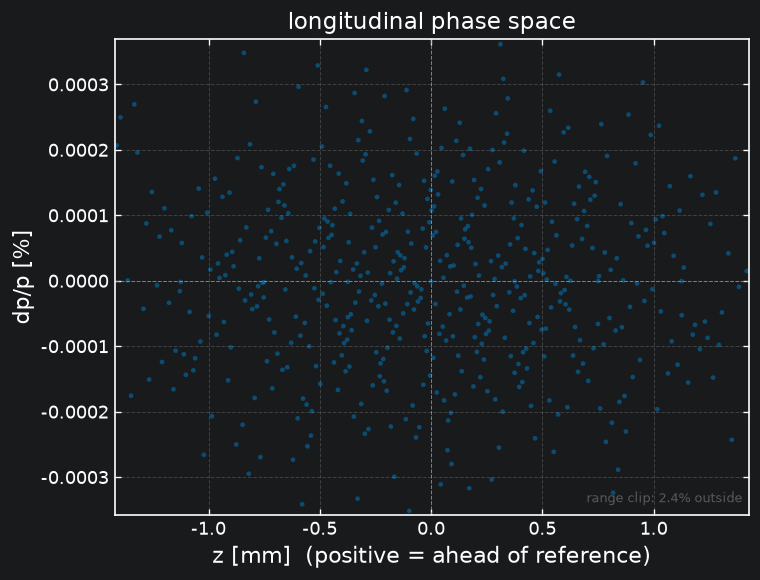

In [3]:
from astra_tools.widgets.selectors import PhaseStepper
from IPython.display import display
from ipywidgets import interactive_output
import ipywidgets as widgets
from astra_tools.io import read_distribution
from astra_tools.analysis.statistics import compute_statistics
from astra_tools.widgets.panels import stats_table_html
from astra_tools.plot.phase_space import plot_transverse_phase_space, plot_phase_space

ph = [p for p in sorted(work.glob("Example.*.001"))
      if p.name.split(".")[1].lstrip("-").isdigit()]
print("z 位置数:", len(ph))
stepper = PhaseStepper(ph)

out = widgets.Output()

def _update(i):
    with out:
        out.clear_output(wait=True)
        dist = read_distribution(stepper.path)
        stats_table_html(compute_statistics(dist))
        plot_transverse_phase_space(dist)
        plot_phase_space(dist, plane="x", normalize=True,
                         title="x-x 归一化")
        plot_phase_space(dist, plane="z")

display(stepper)
display(interactive_output(_update, {"i": stepper.index}))
_update(stepper.index.value)

## 步进 + 重跑单元

步进改变"当前束团"后, 想看的其它图 (6D 全景/切片/BFF/导出...) 只需
重跑对应单元 — 与原 postpro 的操作逻辑一致 (步进 -> 选择要看的图)。

当前 z: z = 15.000 m  (Example.1500.001)


(<Figure size 1560x1440 with 6 Axes>,
 array([[<Axes: title={'center': "x-x'"}, xlabel='x [mm]', ylabel="x' [mrad]">,
         <Axes: title={'center': 'x-y'}, xlabel='x [mm]', ylabel='y [mm]'>],
        [<Axes: title={'center': "y-y'"}, xlabel='y [mm]', ylabel="y' [mrad]">,
         <Axes: title={'center': 'z-x'}, xlabel='z [mm]', ylabel='x [mm]'>],
        [<Axes: title={'center': 'z-dp/p'}, xlabel='z [mm] (positive = ahead)', ylabel='dp/p [%]'>,
         <Axes: title={'center': 'z-y'}, xlabel='z [mm]', ylabel='y [mm]'>]],
       dtype=object))

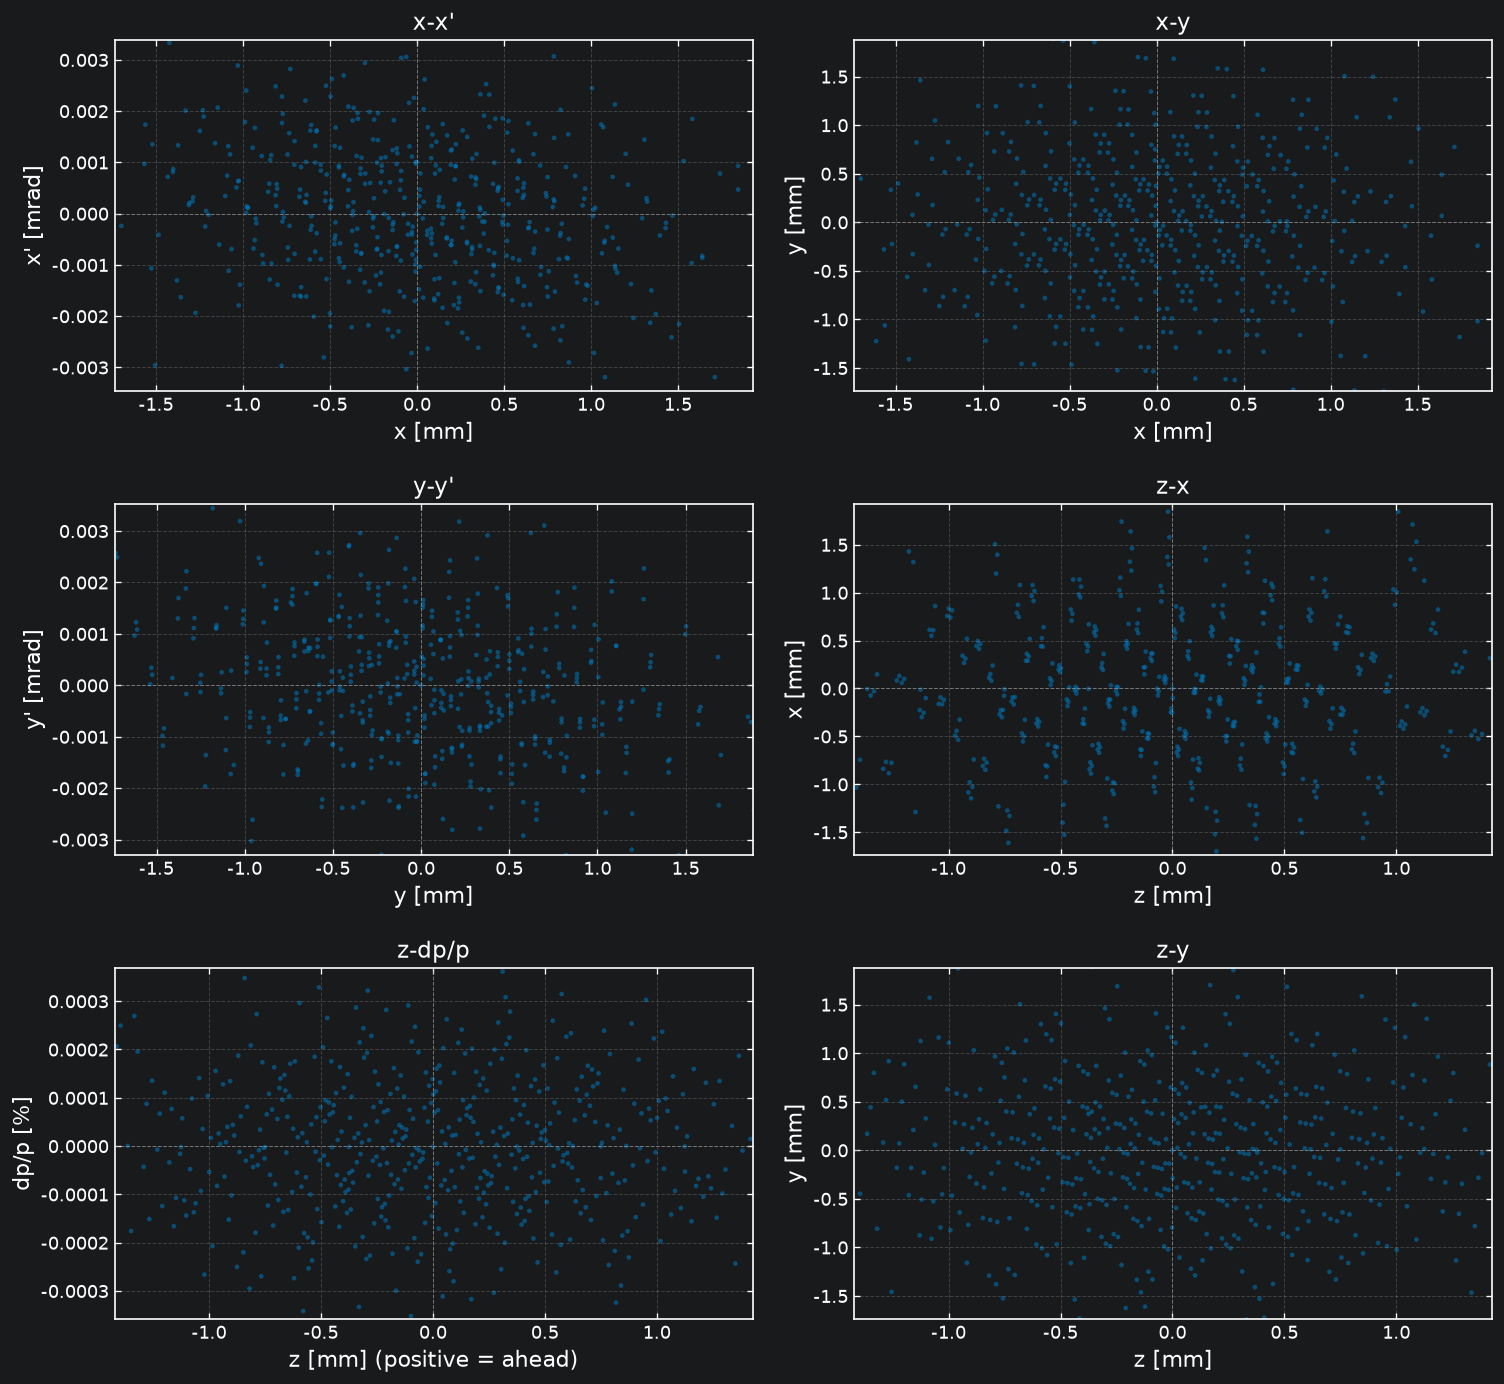

In [4]:
# 例如: 当前 z 位置的 6D 全景
from astra_tools.plot.overview import plot_overview
dist = read_distribution(stepper.path)
print("当前 z:", stepper.label)
plot_overview(dist)